# MLB Game Winner — Data Pipeline

Loads raw game logs, engineers features (season-to-date, rolling, Bayesian),
and saves the final feature matrix to disk for use by the training notebook.


## 1. Setup

In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
pd.set_option('display.max_columns',None)

# Add model directory to path so local imports work
MODEL_DIR = os.path.abspath(".")
if MODEL_DIR not in sys.path:
    sys.path.insert(0, MODEL_DIR)

import pybaseball
pybaseball.cache.enable()

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from features import build_team_stats, game_features, feature_columns, TEAM_NAME_TO_ABB
from train import build_training_data

ARTIFACTS_DIR = os.path.join(MODEL_DIR, "artifacts")
MODEL_PATH = os.path.join(ARTIFACTS_DIR, "model.pkl")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print(f"Model dir: {MODEL_DIR}")
print(f"Artifacts: {ARTIFACTS_DIR}")



/Users/nickchapman/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Model dir: /Users/nickchapman/pitch_predictor/backend/model
Artifacts: /Users/nickchapman/pitch_predictor/backend/model/artifacts


In [2]:
import mlflow
import mlflow.sklearn

MLFLOW_TRACKING_URI = os.path.join(MODEL_DIR, "mlruns")
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("mlb-game-predictor-v1")
print(f"MLflow tracking URI: {MLFLOW_TRACKING_URI}")


MLflow tracking URI: /Users/nickchapman/pitch_predictor/backend/model/mlruns


## 2. Configure Training Years

In [3]:
# Adjust years as needed. 2020 is a shortened 60-game season.
YEARS = [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

## 3. Inspect Team Stats (Single Season)

In [4]:
sample_year = 2024
stats = build_team_stats(sample_year)
print(f"{sample_year} team stats: {stats.shape}")
stats.sort_values('obp')

2024 team stats: (30, 7)


,rpg,rapg,obp,slg,bb_pct,k_pct,wpct
TBR,2.533333,2.533333,0.267961,0.337500,0.052427,0.267961,0.493827
KCR,2.800000,3.066667,0.274725,0.293033,0.091241,0.253650,0.519231
BOS,2.866667,3.533333,0.275362,0.300403,0.083183,0.269439,0.493750
CHW,3.733333,3.400000,0.276481,0.357422,0.067979,0.225403,0.243590
SFG,4.200000,3.600000,0.279197,0.395669,0.061931,0.265938,0.487500
CLE,3.400000,2.866667,0.283270,0.389234,0.070209,0.237192,0.601307
OAK,3.133333,4.866667,0.288288,0.338583,0.075404,0.256732,0.430380
PIT,2.866667,4.466667,0.289377,0.361055,0.084249,0.278388,0.474684
WSN,2.933333,4.200000,0.291045,0.350202,0.068519,0.220370,0.430380
CIN,3.533333,4.533333,0.296846,0.338174,0.086876,0.221811,0.481250


In [5]:
teams = stats.index.tolist()

In [6]:
teams

['ARI',
 'ATL',
 'BAL',
 'BOS',
 'CHC',
 'CHW',
 'CIN',
 'CLE',
 'COL',
 'DET',
 'HOU',
 'KCR',
 'LAA',
 'LAD',
 'MIA',
 'MIL',
 'MIN',
 'NYM',
 'NYY',
 'OAK',
 'PHI',
 'PIT',
 'SDP',
 'SEA',
 'SFG',
 'STL',
 'TBR',
 'TEX',
 'TOR',
 'WSN']

## 4. Inspect Game Logs (Single Season)

In [7]:
# logs = _get_game_logs(sample_year)
# home_games = logs[logs["Home_Away"] == "Home"]
# print(f"{sample_year} home games: {len(home_games)}")
# print("W/
# L distribution:")
# print(home_games["W/L"].str.strip().str.upper().value_counts())
# home_games.head(5)

In [8]:
from pybaseball.datasources.bref import BRefSession
session = BRefSession()
_URL = "https://www.baseball-reference.com/teams/tgl.cgi?team={}&t={}&year={}"

def get_table(season: int, team: str, log_type: str) -> pd.DataFrame:
    t_param = "b" if log_type == "batting" else "p"
    content = session.get(_URL.format(team, t_param, season)).content
    soup = BeautifulSoup(content, "lxml")
    table_id = "players_standard_{}".format(log_type)
    table = soup.find("table", attrs=dict(id=table_id))
    if table is None:
        raise RuntimeError("Table with expected id not found on scraped page.")
    data = pd.read_html(StringIO(str(table)))[0]
    return data
def postprocess(data: pd.DataFrame) -> pd.DataFrame:
    #print(data.columns)
    data.drop([('Unnamed: 0_level_0', 'Rk')], axis=1, inplace=True)  # drop index column
    data = data.iloc[:-1]
    repl_dict = {
        "Gtm" : "Game",
        "Unnamed: 3_level_1": "Home",
        "#": "NumPlayers",
        "Opp. Starter (GmeSc)": "OppStart",
        "Pitchers Used (Rest-GameScore-Dec)": "PitchersUsed"
    }
    data = data.rename(columns= repl_dict).copy()
    data[('Unnamed: 3_level_0','Home')] = data[('Unnamed: 3_level_0','Home')].isnull()  # '@' if away, empty if home
    data = data[data[('Unnamed: 1_level_0','Game')] != 'Gtm'].copy()  # drop empty month rows
    data = data.apply(pd.to_numeric, errors="ignore")
    data[('Unnamed: 1_level_0','Game')] = data[('Unnamed: 1_level_0','Game')].astype(int)
    return data.reset_index(drop=True)


def team_game_logs(season: int, team: str, log_type: str="batting") -> pd.DataFrame:
    """
    Get Baseball Reference batting or pitching game logs for a team-season.

    :param season: year of logs
    :param team: team abbreviation
    :param log_type: "batting" (default) or "pitching"
    :return: pandas.DataFrame of game logs
    """
    if log_type not in ("batting", "pitching"):
        raise ValueError("`log_type` must be either 'batting' or 'pitching'.")
    data = get_table(season, team, log_type)
    data = postprocess(data)
    return data

In [9]:
# failures = []
# for team in teams:
#     for year in YEARS:
#         for log_type in ['batting','pitching']:
#             try:
#                 game_logs_test = team_game_logs(season=year,team=team,log_type=log_type)
#                 game_logs_test.columns = game_logs_test.columns.droplevel()
#                 game_logs_test.to_parquet(f"{log_type}_{team}_{year}_logs.parquet")
#             except:
#                 print(f"{team} + {year} + {log_type} failed")
#                 failures.append([team, year, log_type])
                
        

In [10]:
# for each in failures:
#     year = each[1]
#     team = 'ATH'
#     log_type=each[2]
#     print(year, team, log_type)
#     game_logs_test = team_game_logs(season=year,team=team,log_type=log_type)
#     game_logs_test.columns = game_logs_test.columns.droplevel()
#     game_logs_test.to_parquet(f"{log_type}_{team}_{year}_logs.parquet")

## 5. Build Full Training Dataset

In [11]:
import glob

files = glob.glob("./artifacts/game_log_data/*.parquet")
def read_file(x):
    temp = pd.read_parquet(x)
    temp['season'] = x.split("/")[-1].split('_')[2]
    temp['log_type'] = x.split("/")[-1].split('_')[0]
    temp['team'] = x.split("/")[-1].split('_')[1].replace('ATH','OAK')
    return(temp)
    
game_logs = pd.concat([read_file(f) for f in files], ignore_index=True).reset_index(drop=True)

In [12]:
home_games_pitching = game_logs.query("(Home==True) & (log_type=='pitching')").copy()
away_games_pitching = game_logs.query("(Home==False) & (log_type=='pitching')").copy()

home_games_batting = game_logs.query("(Home==True) & (log_type=='batting')").copy()
away_games_batting = game_logs.query("(Home==False) & (log_type=='batting')").copy()

In [13]:
home_games_batting = home_games_batting.dropna(axis=1, how='all')
home_games_pitching = home_games_pitching.dropna(axis=1, how='all')

away_games_batting = away_games_batting.dropna(axis=1, how='all')
away_games_pitching = away_games_pitching.dropna(axis=1, how='all')

In [14]:
home_games_batting.columns = ['home_batting_' + x if x not in ('team', 'Opp', 'Date') else x for x in home_games_batting.columns]
home_games_pitching.columns = ['home_pitching_' + x if x not in ('team', 'Opp', 'Date') else x for x in home_games_pitching.columns]
away_games_batting.columns = ['away_batting_' + x if x not in ('team', 'Opp', 'Date') else x for x in away_games_batting.columns]
away_games_pitching.columns = ['away_pitching_' + x if x not in ('team', 'Opp', 'Date') else x for x in away_games_pitching.columns]

In [15]:
### each row needs to be a combination of home batting + pitching and away batting + pitching

In [16]:
home_games_batting.shape

(15813, 40)

In [17]:
home_games = home_games_batting\
    .merge(home_games_pitching, on=['team','Date','Opp'])
away_games = away_games_batting\
    .merge(away_games_pitching, on=['team','Date','Opp'])
full_game_dataset = pd.concat([home_games, away_games])

In [18]:
away_games['Opp'] = away_games['Opp'].replace('ATH','OAK')

In [19]:
## Trying to predict whether team in question will win. Need whether they are home / away. Need home batting, opp batting, home pitching, away pitching

In [20]:
full_dataset = home_games.merge(away_games, left_on=['team','Date'], right_on=['Opp','Date'], suffixes=['_home','_away'])

In [21]:
full_dataset['target'] = full_dataset['home_batting_Rslt'].map({'L': 0, 'W': 1})


### Compute Season-to-date & Rolling 10 

In [22]:
# separate batting and pitching
batting = game_logs[game_logs['log_type'] == 'batting'].copy()
pitching = game_logs[game_logs['log_type'] == 'pitching'].copy()

# define stat cols for each
batting_stat_cols = ['PA', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 
                     'BB', 'SO', 'BA', 'OBP', 'SLG', 'OPS', 'TB', 'GIDP', 'HBP', 
                     'SH', 'SF', 'ROE', 'IBB', 'BAbip', 'LOB']

pitching_stat_cols = ['IP', 'ER', 'HR', 'BB', 'IBB', 'SO', 'HBP', 'BK', 'WP', 'BF', 
                      'ERA', 'FIP', 'Pit', 'Str', 'StL', 'StS', 'GB', 'FB', 'LD', 
                      'PU', 'Unk', 'IR', 'IS', 'PO']

WINDOW = 10

# sort
batting = batting.sort_values(['team', 'season', 'Date']).reset_index(drop=True)
pitching = pitching.sort_values(['team', 'season', 'Date']).reset_index(drop=True)

# season-to-date and rolling features
for stat_cols, df, name in [(batting_stat_cols, batting, 'batting'), 
                             (pitching_stat_cols, pitching, 'pitching')]:
    grp = df.groupby(['team', 'season'])[stat_cols]
    
    std = grp.transform(lambda x: x.shift(1).expanding().mean()).add_suffix('_std')
    roll = grp.transform(lambda x: x.shift(1).rolling(WINDOW, min_periods=1).mean()).add_suffix(f'_roll{WINDOW}')
    
    if name == 'batting':
        batting = pd.concat([batting, std, roll], axis=1)
    else:
        pitching = pd.concat([pitching, std, roll], axis=1)

### Add Bayesian Features

In [23]:
WINDOW = 10

# --- compute priors from previous season ---
def compute_priors(df, stat_cols):
    """Compute mean and variance per team per season to use as next season's prior."""
    return (
        df.groupby(['team', 'season'])[stat_cols]
        .agg(['mean', 'var'])
        .reset_index()
    )

# flatten multiindex columns
def flatten_prior_cols(prior_df):
    prior_df.columns = ['team', 'season'] + [f'{col}_{agg}' for col, agg in prior_df.columns[2:]]
    return prior_df

def flatten_league_prior_cols(prior_df):
    prior_df.columns = ['season'] + [f'{col}_{agg}' for col, agg in prior_df.columns[1:]]
    return prior_df

batting_priors = flatten_prior_cols(compute_priors(batting, batting_stat_cols))
pitching_priors = flatten_prior_cols(compute_priors(pitching, pitching_stat_cols))

# shift season by 1 so prior from season N applies to season N+1
batting_priors['season'] = batting_priors['season'].astype(int) + 1
pitching_priors['season'] = pitching_priors['season'].astype(int) + 1

# --- league average fallback per season ---
def compute_league_priors(df, stat_cols):
    return (
        df.groupby('season')[stat_cols]
        .agg(['mean', 'var'])
        .reset_index()
    )

batting_league = flatten_league_prior_cols(compute_league_priors(batting, batting_stat_cols))
pitching_league = flatten_league_prior_cols(compute_league_priors(pitching, pitching_stat_cols))


# --- bayesian update function ---
def bayesian_update_group(observations, prior_mean, prior_var):
    """
    Returns posterior mean and variance before each game (pre-game estimate).
    Uses normal-normal conjugate with likelihood variance = prior variance.
    """
    mus = []
    vars_ = []
    
    mu, var = prior_mean, prior_var
    
    for x in observations:
        mus.append(mu)   # record BEFORE update (pre-game)
        vars_.append(var)
        
        # conjugate update
        var_new = 1 / (1/var + 1/prior_var)
        mu_new = var_new * (mu/var + x/prior_var)
        
        mu, var = mu_new, var_new
    
    return mus, vars_


# --- apply per team per season per stat ---
def apply_bayesian(df, stat_cols, team_priors, league_priors):
    results = []
    
    for (team, season), group in df.sort_values(['team', 'season', 'Date']).groupby(['team', 'season']):
        group = group.copy()
        
        team_prior = team_priors[(team_priors['team'] == team) & (team_priors['season'] == season)]
        league_prior = league_priors[league_priors['season'] == season]
        
        for stat in stat_cols:
            mean_col = f'{stat}_mean'
            var_col = f'{stat}_var'
            
            # get prior — fall back to league if no team prior
            if not team_prior.empty and mean_col in team_prior.columns:
                p_mean = team_prior[mean_col].values[0]
                p_var = team_prior[var_col].values[0]
            else:
                p_mean = league_prior[mean_col].values[0]
                p_var = league_prior[var_col].values[0]
            
            # handle zero/nan variance
            if pd.isna(p_var) or p_var == 0:
                p_var = league_prior[var_col].values[0]
            if pd.isna(p_var) or p_var == 0:
                p_var = 1e-6
            
            obs = group[stat].values
            mus, vars_ = bayesian_update_group(obs, p_mean, p_var)
            
            group[f'{stat}_bayes_mean'] = mus
            group[f'{stat}_bayes_var'] = vars_
        
        results.append(group)
    
    return pd.concat(results).reset_index(drop=True)


# --- run ---
batting = apply_bayesian(batting, batting_stat_cols, batting_priors, batting_league)
pitching = apply_bayesian(pitching, pitching_stat_cols, pitching_priors, pitching_league)

In [24]:
batting.head()

,Game,Date,Home,Opp,Rslt,RS,RA,Inn,PA,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,BA,OBP,SLG,OPS,TB,GIDP,HBP,SH,SF,ROE,IBB,BAbip,LOB,NumPlayers,Player,T,GmSc,season,log_type,team,IP,ER,BK,WP,BF,ERA,FIP,Pit,Str,StL,StS,GB,FB,LD,PU,Unk,IR,IS,PO,Umpire,PitchersUsed,PA_std,AB_std,R_std,H_std,2B_std,3B_std,HR_std,RBI_std,SB_std,CS_std,BB_std,SO_std,BA_std,OBP_std,SLG_std,OPS_std,TB_std,GIDP_std,HBP_std,SH_std,SF_std,ROE_std,IBB_std,BAbip_std,LOB_std,PA_roll10,AB_roll10,R_roll10,H_roll10,2B_roll10,3B_roll10,HR_roll10,RBI_roll10,SB_roll10,CS_roll10,BB_roll10,SO_roll10,BA_roll10,OBP_roll10,SLG_roll10,OPS_roll10,TB_roll10,GIDP_roll10,HBP_roll10,SH_roll10,SF_roll10,ROE_roll10,IBB_roll10,BAbip_roll10,LOB_roll10,PA_bayes_mean,PA_bayes_var,AB_bayes_mean,AB_bayes_var,R_bayes_mean,R_bayes_var,H_bayes_mean,H_bayes_var,2B_bayes_mean,2B_bayes_var,3B_bayes_mean,3B_bayes_var,HR_bayes_mean,HR_bayes_var,RBI_bayes_mean,RBI_bayes_var,SB_bayes_mean,SB_bayes_var,CS_bayes_mean,CS_bayes_var,BB_bayes_mean,BB_bayes_var,SO_bayes_mean,SO_bayes_var,BA_bayes_mean,BA_bayes_var,OBP_bayes_mean,OBP_bayes_var,SLG_bayes_mean,SLG_bayes_var,OPS_bayes_mean,OPS_bayes_var,TB_bayes_mean,TB_bayes_var,GIDP_bayes_mean,GIDP_bayes_var,HBP_bayes_mean,HBP_bayes_var,SH_bayes_mean,SH_bayes_var,SF_bayes_mean,SF_bayes_var,ROE_bayes_mean,ROE_bayes_var,IBB_bayes_mean,IBB_bayes_var,BAbip_bayes_mean,BAbip_bayes_var,LOB_bayes_mean,LOB_bayes_var
0,1,2019-03-28,False,LAD,L,5,12,9,35.0,33,5,9,4,0,2,5.0,0,0,0,10,0.273,0.257,0.576,0.833,19.0,1,0,0.0,2,0,0,0.304,3.0,11,Hyun Jin Ryu,L,68.0,2019,batting,ARI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.393783,29.704281,34.304446,20.179684,4.830589,11.038414,8.653561,12.280820,1.756072,1.972812,0.161589,0.170095,1.394813,1.612672,4.625566,10.416699,0.469329,0.645240,0.171264,0.166257,3.271923,4.363556,8.814944,9.562000,0.248472,0.000366,0.320708,0.000522,0.426829,0.002145,0.747526,0.004423,14.917250,48.859529,0.712845,0.675812,0.408399,0.443841,0.159737,0.160602,0.236723,0.242077,0.321120,0.327991,0.155002,0.172181,0.291413,0.009124,6.747633,6.784558
1,2,2019-03-29,False,LAD,W,5,4,13,56.0,50,5,10,3,0,1,5.0,1,0,6,15,0.229,0.275,0.422,0.696,16.0,0,0,0.0,0,0,2,0.265,12.0,18,Ross Stripling,R,66.0,2019,batting,ARI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.0,33.000000,5.0,9.000000,4.000000,0.00,2.000000,5.0,0.000000,0.0,0.0,10.000000,0.273000,0.25700,0.576000,0.833000,19.0,1.0,0.0,0.0,2.000000,0.0,0.000000,0.304000,3.0,35.0,33.000000,5.0,9.000000,4.000000,0.00,2.000000,5.0,0.000000,0.0,0.0,10.000000,0.273000,0.25700,0.576000,0.833000,19.0,1.0,0.0,0.0,2.000000,0.0,0.000000,0.304000,3.0,36.696892,14.852140,33.652223,10.089842,4.915294,5.519207,8.826781,6.140410,2.878036,0.986406,0.080795,0.085048,1.697406,0.806336,4.812783,5.208349,0.234664,0.322620,0.085632,0.083128,1.635961,2.181778,9.407472,4.781000,0.260736,0.000183,0.288854,0.000261,0.501414,0.001073,0.790263,0.002211,16.958625,24.429765,0.856422,0.337906,0.204199,0.221921,0.079868,0.080301,1.118361,0.121039,0.160560,0.163996,0.077501,0.086091,0.297706,0.004562,4.873816,3.392279
2,3,2019-03-30,False,LAD,L,5,18,9,35.0,32,5,7,0,0,4,5.0,0,0,3,7,0.226,0.278,0.470,0.747,19.0,2,0,0.0,0,0,0,0.143,3.0,13,Kenta Maeda,R,56.0,2019,batting,ARI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.5,41.500000,5.0,9.500000,3.500000,0.00,1.500000,5.0,0.500000,0.0,3.0,12.500000,0.251000,0.26600,0.499000,0.764500,17.5,0.5,0.0,0.0,1.000000,0.0,1.000000,0.284500,7.5,45.5,41.500000,5.0,9.500000,3.500000,0.00,1.500000,5.0,0.500000,0.0,3.0,12.500000,0.251000,0.26600,0.499000,0.764500,17.5,0.5,0.0,0.0,1.000000,0.0,1.000000,0.284500,7.5,43.131261,9.901427,39.101482,6.726561,4.943530,3.679471,9.217854,4.093607,2.918691,0.6

In [25]:
join_keys = ['team', 'Date', 'season']

full_dataset = (
    full_dataset
    .merge(batting[join_keys + [c for c in batting.columns if c.endswith(('_std', '_roll10','_bayes_var','_bayes_mean'))]],
           left_on=['team_home', 'Date', 'home_batting_season'],
           right_on=join_keys, suffixes=('', '_home_bat'))
    .merge(pitching[join_keys + [c for c in pitching.columns if c.endswith(('_std', '_roll10','_bayes_var','_bayes_mean'))]],
           left_on=['team_home', 'Date', 'home_batting_season'],
           right_on=join_keys, suffixes=('', '_home_pit'))
    .merge(batting[join_keys + [c for c in batting.columns if c.endswith(('_std', '_roll10','_bayes_var','_bayes_mean'))]],
           left_on=['Opp_away', 'Date', 'home_batting_season'],
           right_on=join_keys, suffixes=('', '_away_bat'))
    .merge(pitching[join_keys + [c for c in pitching.columns if c.endswith(('_std', '_roll10','_bayes_var','_bayes_mean'))]],
           left_on=['Opp_away', 'Date', 'home_batting_season'],
           right_on=join_keys, suffixes=('', '_away_pit'))
)

In [26]:
# drop redundant join key dupes
full_dataset = full_dataset.loc[:, ~full_dataset.columns.duplicated()]

In [27]:
# final feature matrix
feature_cols = [c for c in full_dataset.columns if c.endswith(
    ('_bayes_mean', '_bayes_var', '_std', f'_roll{WINDOW}', 
     '_home_bat', '_home_pit', '_away_bat', '_away_pit')
)]



In [28]:
final_features = list(set(feature_cols).difference(full_dataset[feature_cols].select_dtypes(exclude='number').columns.tolist()))

In [30]:
sparse_cols = [c for c in full_dataset.columns if any(c.startswith(s) for s in ['IS_', 'IR_', 'PO_'])]
full_dataset[sparse_cols] = full_dataset[sparse_cols].fillna(0)

In [31]:
for col in [c for c in full_dataset.columns if c.endswith('_std') or c.endswith(f'_roll{WINDOW}')]:
    stat = col.rsplit('_', 1)[0]  # strip suffix
    bayes_col = f'{stat}_bayes_mean'
    if bayes_col in full_dataset.columns:
        full_dataset[col] = full_dataset[col].fillna(full_dataset[bayes_col])

In [32]:
X = full_dataset[full_dataset['Date']<'2026-01-01'][final_features]
y = full_dataset[full_dataset['Date']<'2026-01-01']['target']

holdout_X = full_dataset[full_dataset['Date']>='2026-01-01'][final_features]
holdout_y = full_dataset[full_dataset['Date']>='2026-01-01']['target']


In [33]:
print(X.isnull().sum().sum())
print(f"Null rows: {X.isnull().any(axis=1).sum()} / {len(X)}")

10506
Null rows: 103 / 15474


In [34]:
std_and_roll_cols = [c for c in X.columns if '_std' in c or f'_roll{WINDOW}' in c]

for col in std_and_roll_cols:
    if X[col].isnull().any():
        # find matching bayes_mean col by looking for overlap in name
        stat_base = col.split('_std')[0].split(f'_roll{WINDOW}')[0]
        bayes_candidates = [c for c in X.columns if c.startswith(stat_base) and c.endswith('_bayes_mean')]
        if bayes_candidates:
            X[col] = X[col].fillna(X[bayes_candidates[0]])

X.isnull().sum().sum()

0

In [35]:
std_and_roll_cols = [c for c in holdout_X.columns if '_std' in c or f'_roll{WINDOW}' in c]

for col in std_and_roll_cols:
    if holdout_X[col].isnull().any():
        # find matching bayes_mean col by looking for overlap in name
        stat_base = col.split('_std')[0].split(f'_roll{WINDOW}')[0]
        bayes_candidates = [c for c in X.columns if c.startswith(stat_base) and c.endswith('_bayes_mean')]
        if bayes_candidates:
            holdout_X[col] = holdout_X[col].fillna(holdout_X[bayes_candidates[0]])

holdout_X.isnull().sum().sum()

0

## 6. Feature Analysis

In [36]:
feat_names = final_features
df_feats = pd.DataFrame(X, columns=feat_names)
df_feats["home_win"] = y

# Mean feature values by outcome
df_feats.groupby("home_win").mean().T

/var/folders/tn/_dnrf8h92zz9ysbz90jdg21w0000gn/T/ipykernel_79069/2603797114.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_feats["home_win"] = y


home_win,0,1
SO_bayes_var_home_pit,0.332517,0.325325
ER_bayes_mean,4.157950,4.051009
IP_roll10,8.807232,8.813837
FIP_bayes_mean,4.212635,4.145440
IS_bayes_var,0.029204,0.028598
...,...,...
WP_roll10,0.342518,0.333539
RBI_std,4.228723,4.324422
BAbip_bayes_mean,0.283932,0.284076
RBI_bayes_mean,4.233014,4.322588


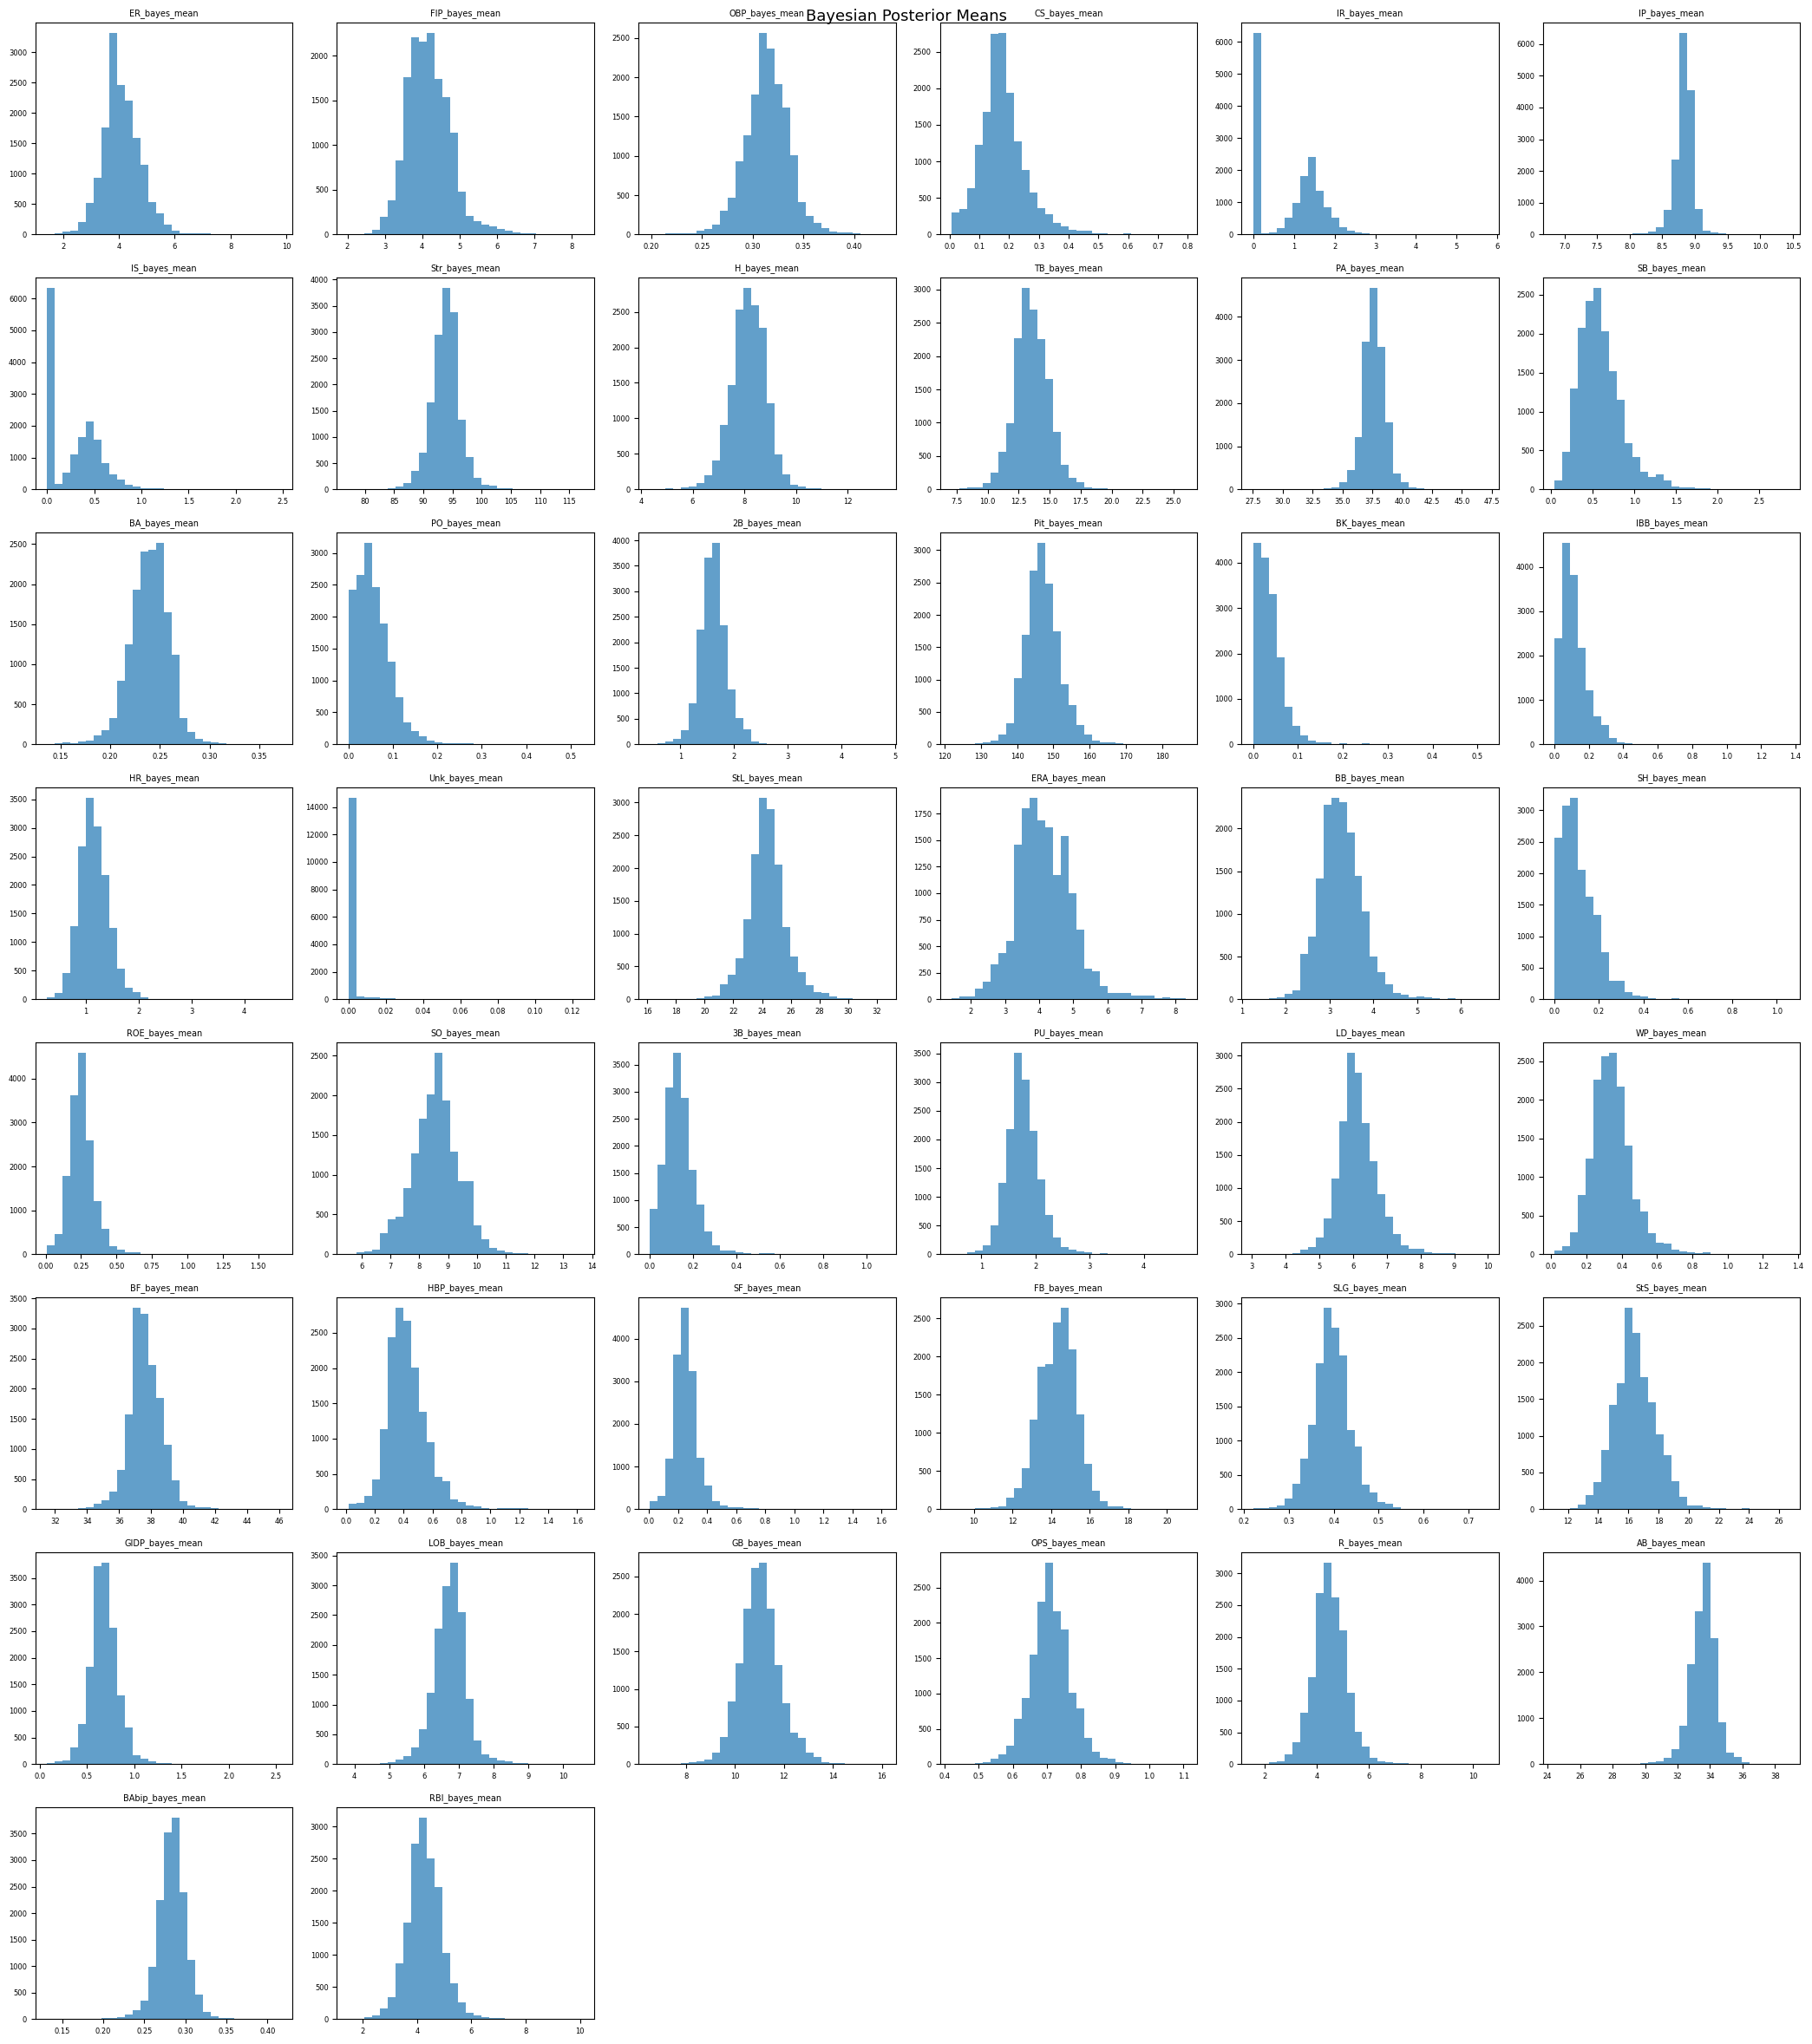

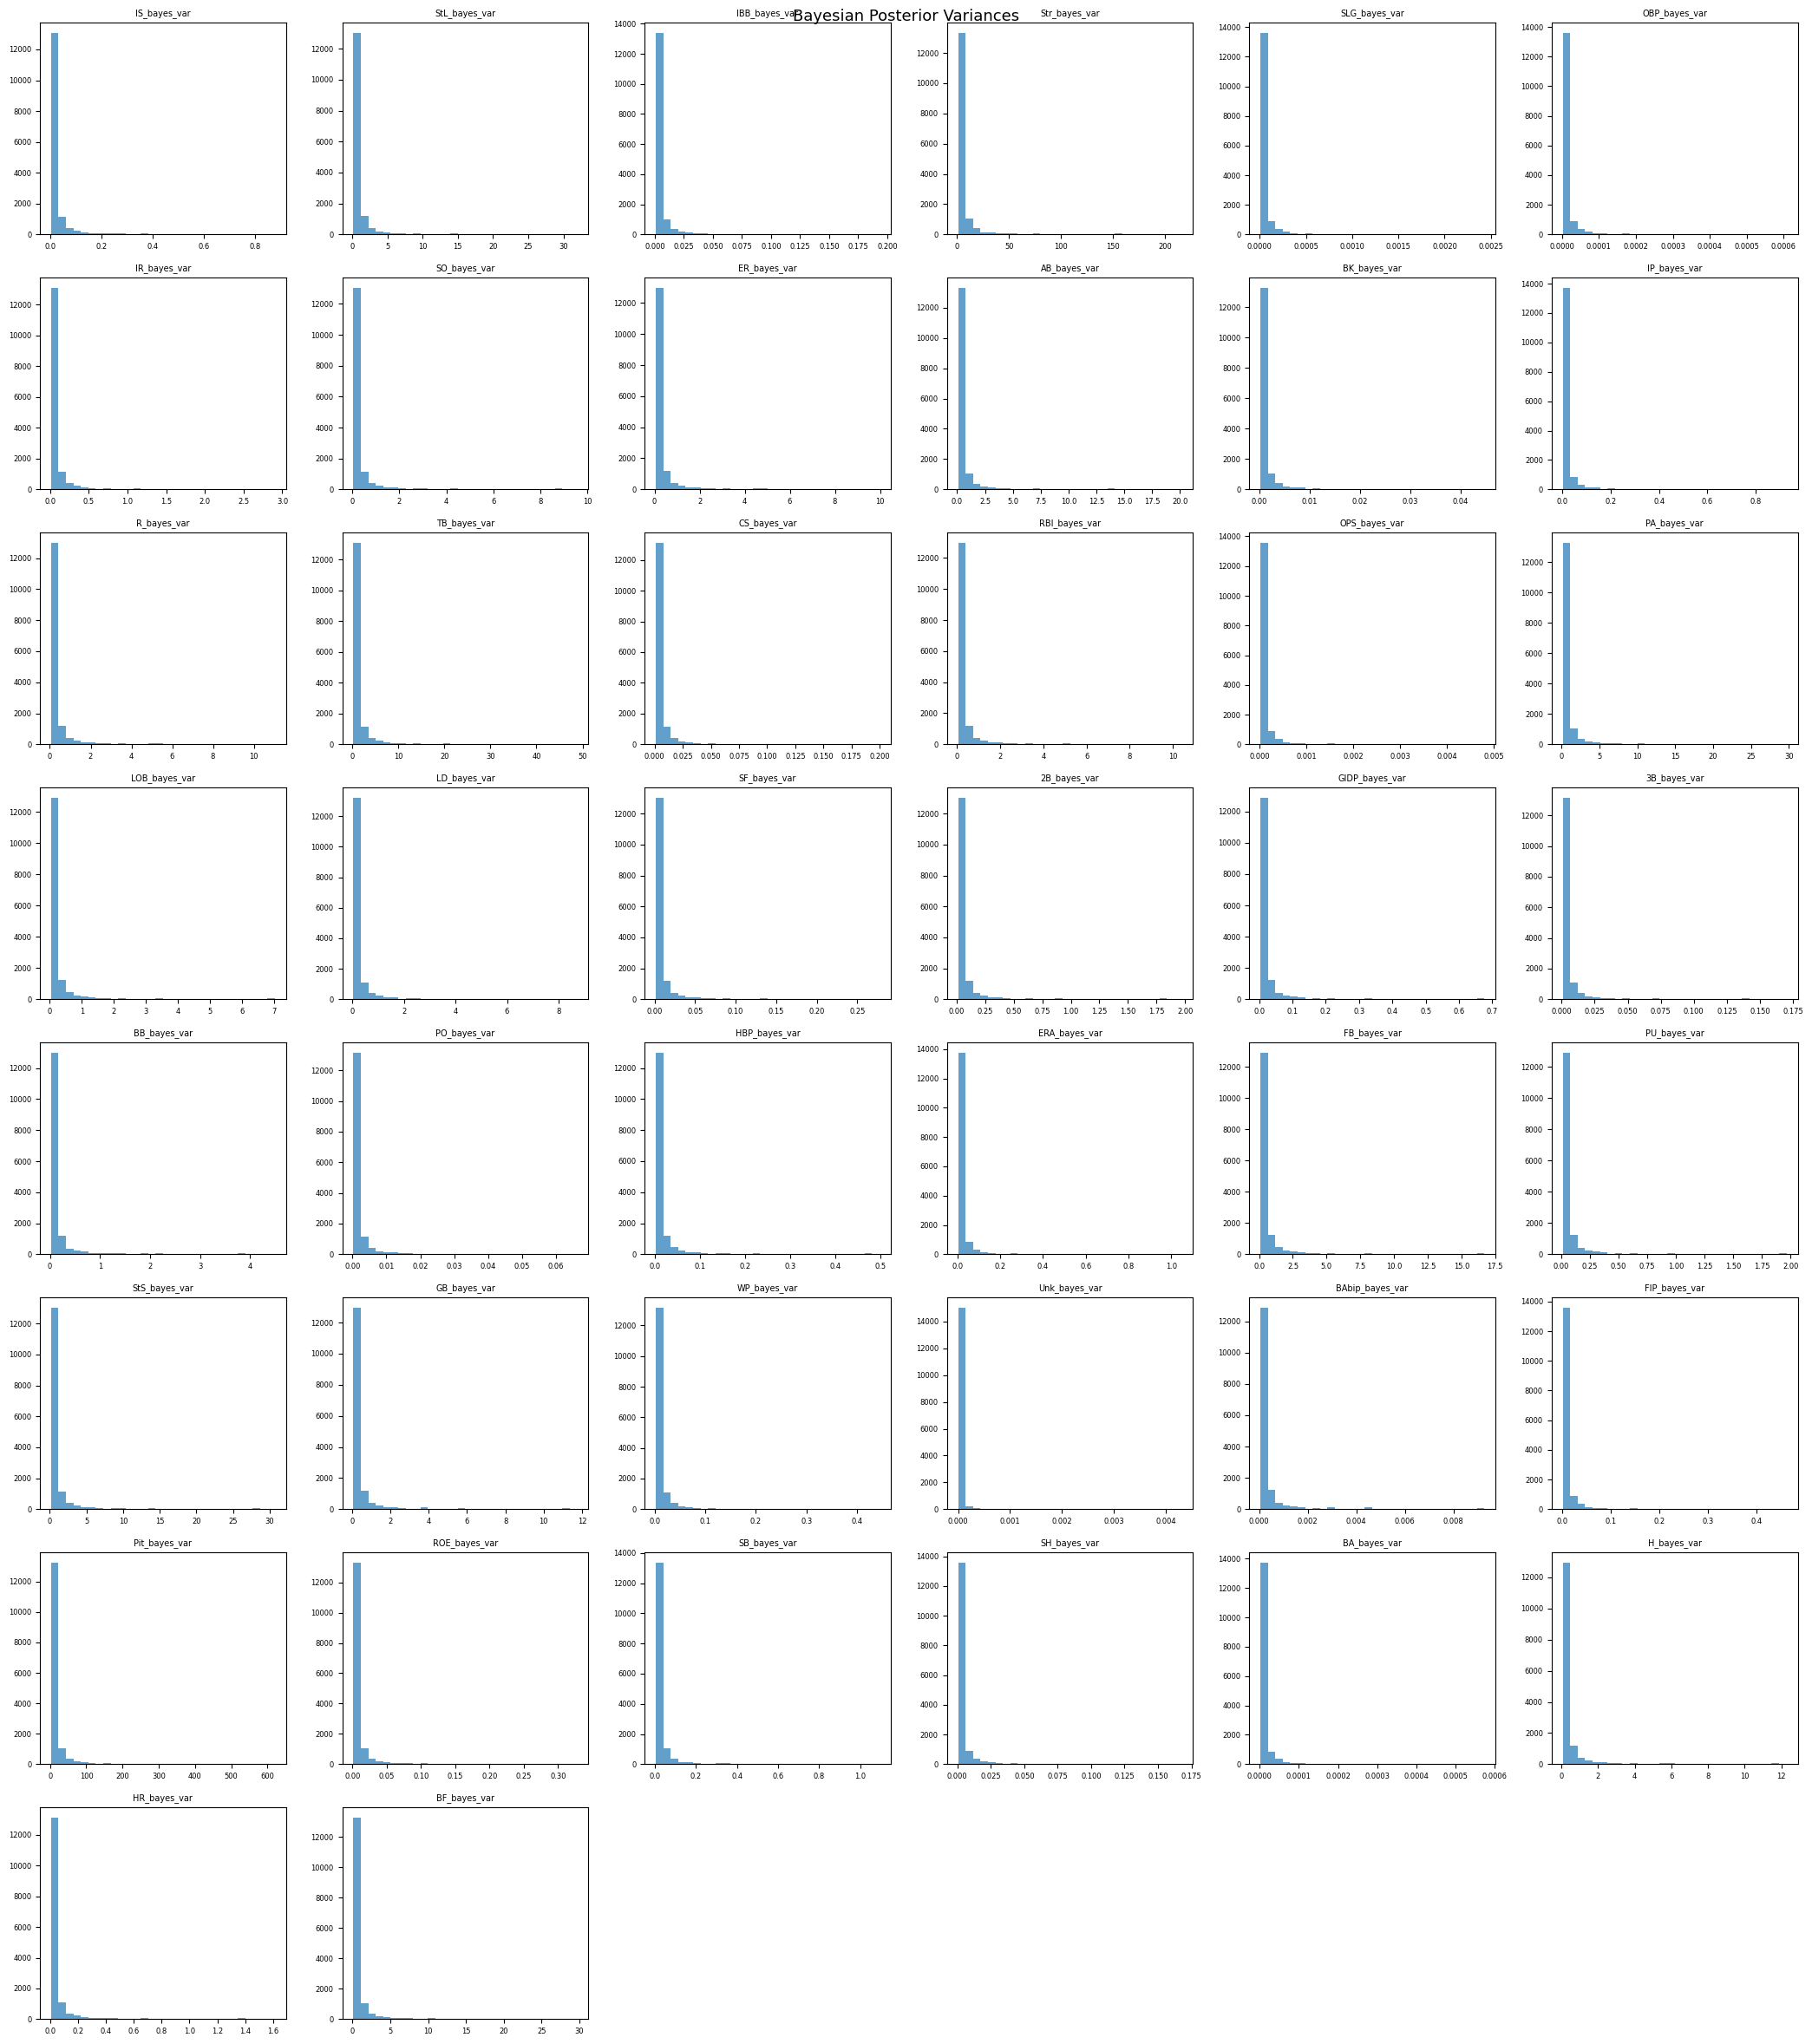

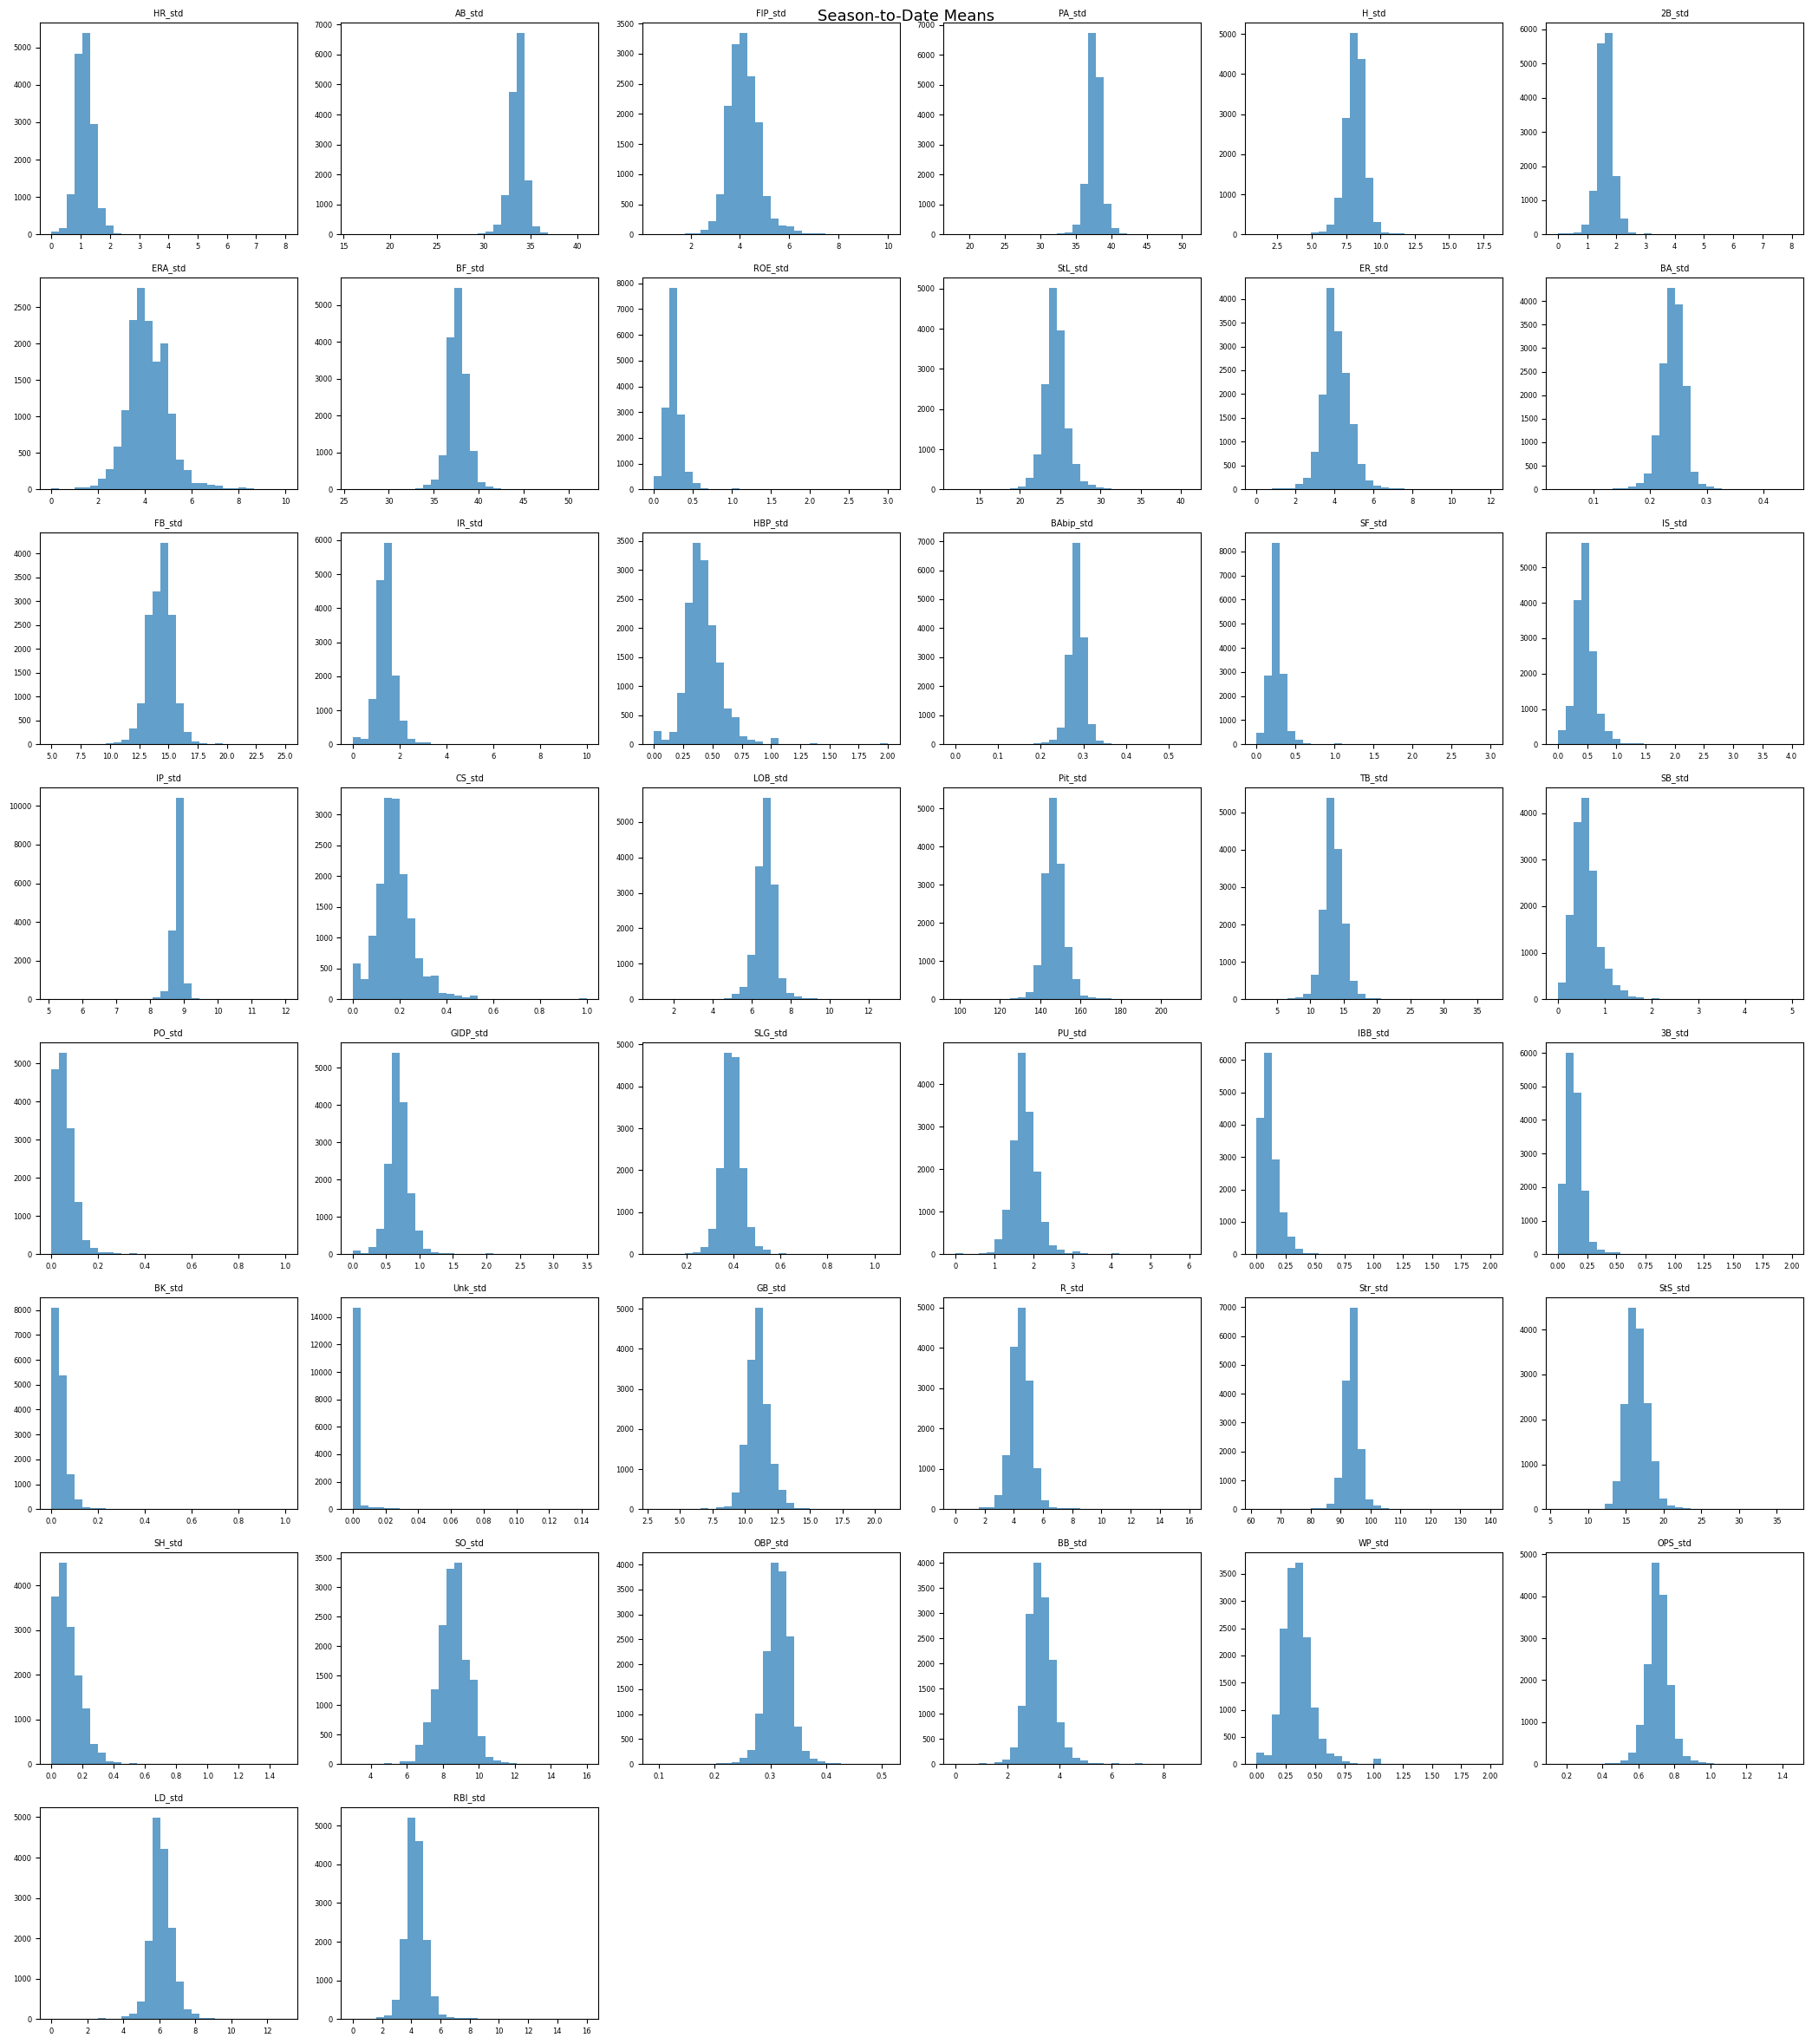

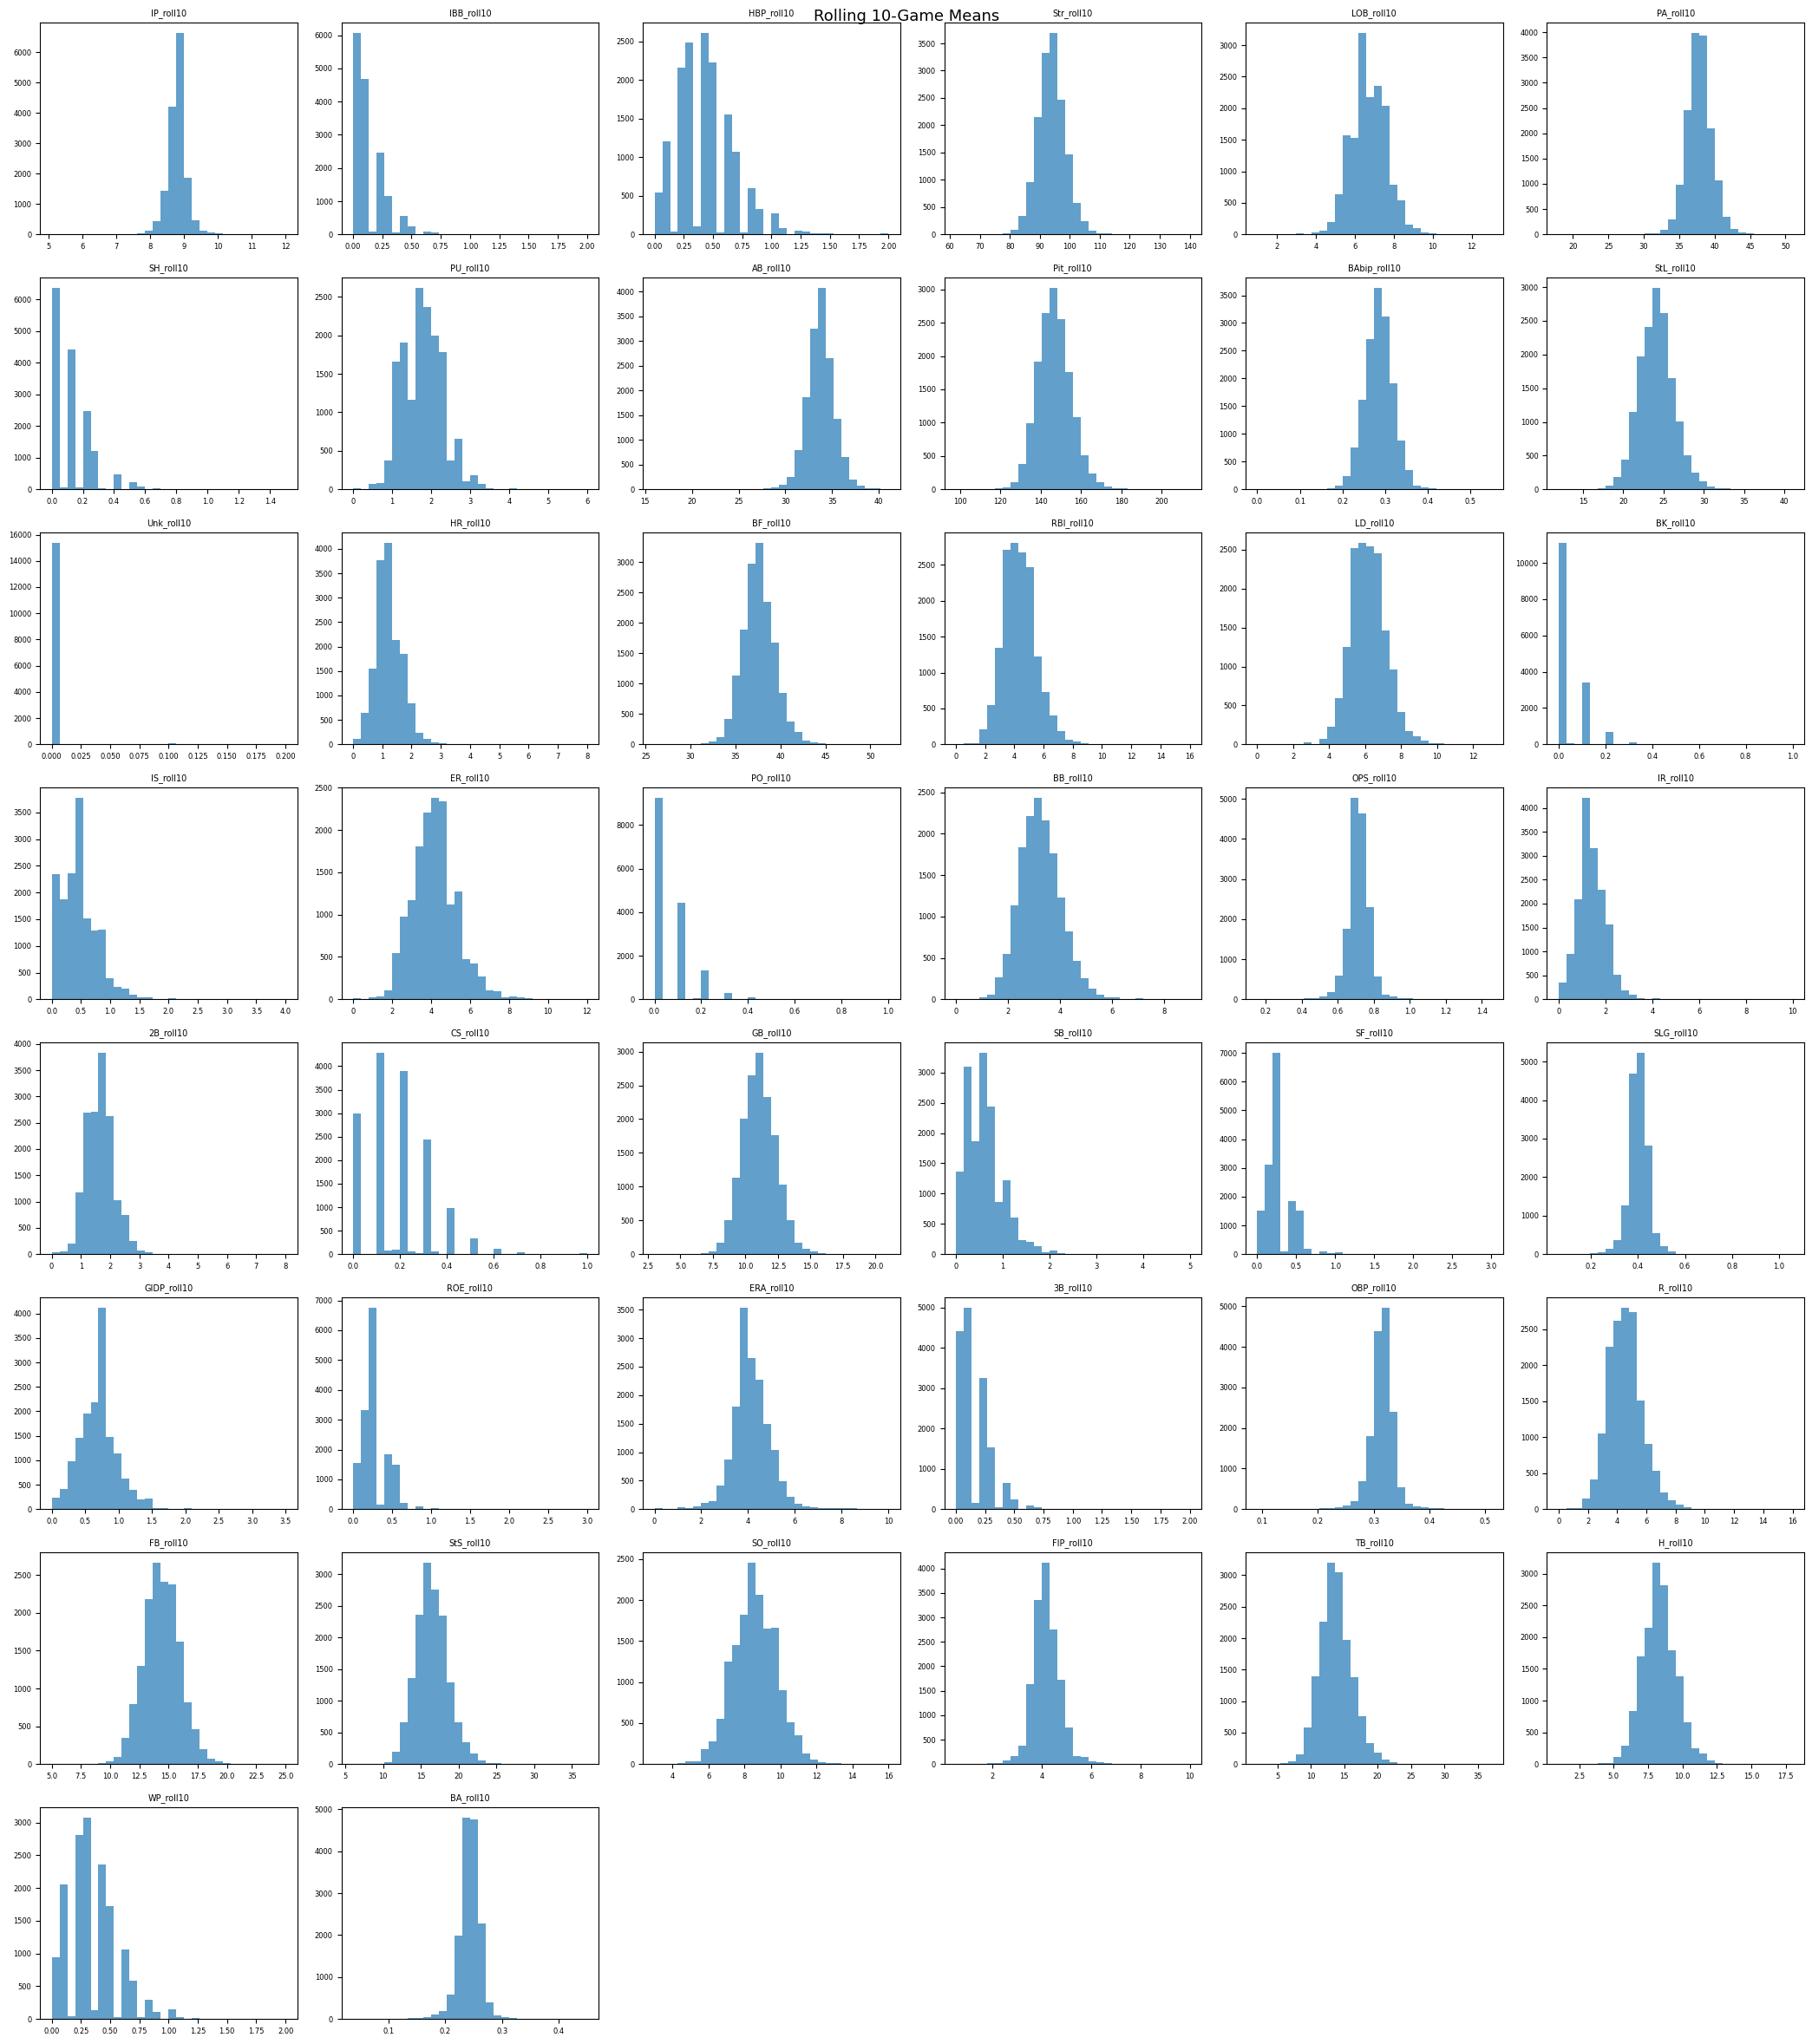

In [37]:
import math

def plot_feature_distributions(df, feature_cols, title, ncols=6):
    nrows = math.ceil(len(feature_cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3))
    axes = axes.flatten()
    
    for i, col in enumerate(feature_cols):
        axes[i].hist(df[col].dropna(), bins=30, alpha=0.7)
        axes[i].set_title(col, fontsize=7)
        axes[i].tick_params(labelsize=6)
    
    for j in range(len(feature_cols), len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

# split by feature type
bayes_mean_cols = [c for c in X.columns if c.endswith('_bayes_mean')]
bayes_var_cols  = [c for c in X.columns if c.endswith('_bayes_var')]
std_cols        = [c for c in X.columns if c.endswith('_std')]
roll_cols       = [c for c in X.columns if c.endswith(f'_roll{WINDOW}')]

plot_feature_distributions(X, bayes_mean_cols, 'Bayesian Posterior Means')
plot_feature_distributions(X, bayes_var_cols,  'Bayesian Posterior Variances')
plot_feature_distributions(X, std_cols,        'Season-to-Date Means')
plot_feature_distributions(X, roll_cols,        f'Rolling {WINDOW}-Game Means')

## 7. Save Dataset

Persists `X`, `y`, `holdout_X`, `holdout_y`, and `final_features`
so the training notebook can load them without re-running the pipeline.


In [38]:
DATA_PATH = os.path.join(ARTIFACTS_DIR, "dataset.pkl")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

with open(DATA_PATH, "wb") as f:
    pickle.dump({
        "X":              X,
        "y":              y,
        "holdout_X":      holdout_X,
        "holdout_y":      holdout_y,
        "final_features": final_features,
        "WINDOW":         WINDOW,
        "YEARS":          YEARS,
    }, f)

size_mb = os.path.getsize(DATA_PATH) / 1024 / 1024
print(f"Saved to {DATA_PATH} ({size_mb:.1f} MB)")
print(f"X: {X.shape}, holdout_X: {holdout_X.shape}, features: {len(final_features)}")


Saved to /Users/nickchapman/pitch_predictor/backend/model/artifacts/dataset.pkl (47.8 MB)
X: (15474, 392), holdout_X: (338, 392), features: 392
